In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn  
import sys
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import joblib
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Matplotlib is building the font cache; this may take a moment.


Using device: cpu


[*********************100%***********************]  1 of 1 completed


{'Dividend Date': datetime.date(2026, 9, 18),
 'Ex-Dividend Date': datetime.date(2026, 9, 3),
 'Earnings Date': [datetime.date(2026, 11, 19)],
 'Earnings High': 17.824,
 'Earnings Low': 14.797,
 'Earnings Average': 16.20688,
 'Revenue High': 30705000000,
 'Revenue Low': 29372126000,
 'Revenue Average': 30311793470}

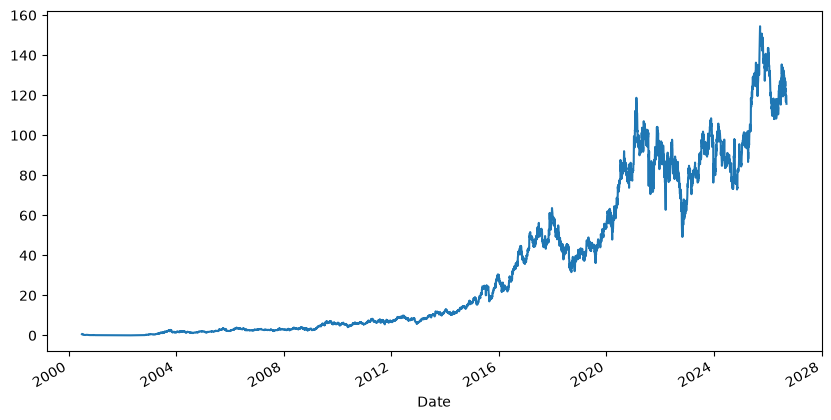

In [3]:
ticker = 'NTES'
df = yf.download(ticker, '2016-01-01')
stock = yf.Ticker(ticker)
stock.info #want to display all this info in the "About" dropdown in web
#TODO: want to create a search button in the web: LET'S NOT MAKE CODE ABOUT THIS FIRST! IT'S #FRAGILE!
#QUERY = yf.Ticker(ticker).query(variables relating to that of query)
history = stock.history(period = "max")
history['Open'].plot(figsize=(10,5))
#goal: let query also handle displaying the stock's split & dividends history
stock.dividends
stock.splits
stock.calendar

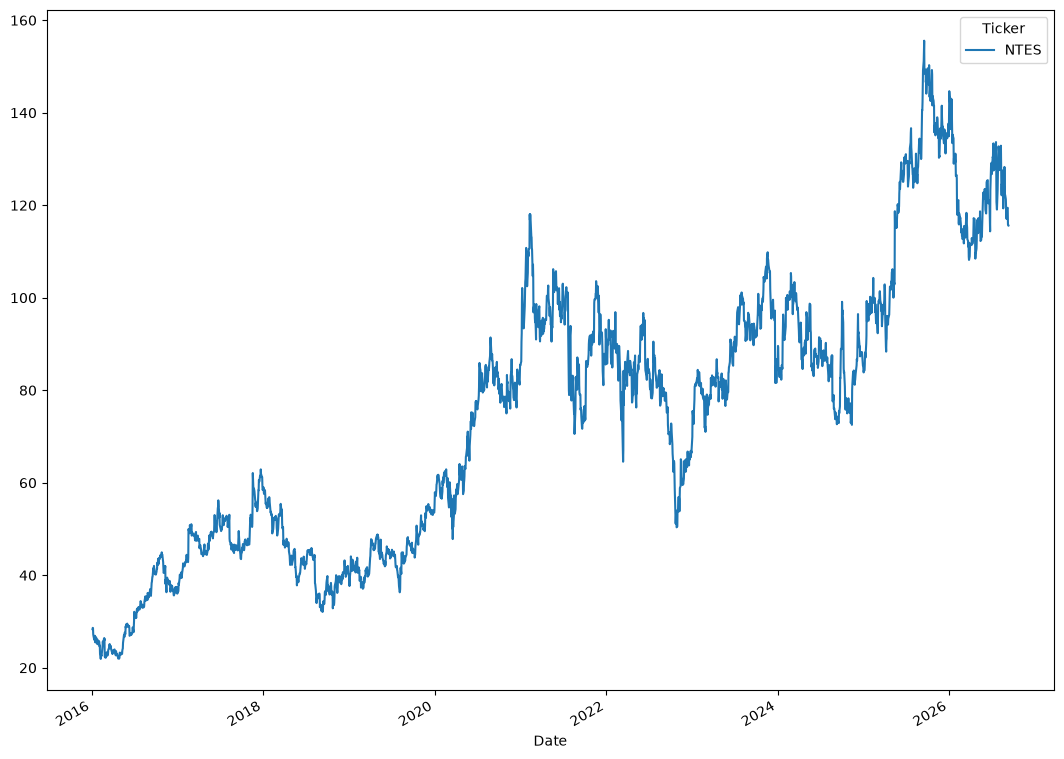

In [4]:
df.Close.plot(figsize=(13,10))
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df['Close'])
df.Close
seq_length = 30  #would prolly like to modify this, for more meaningful predictions
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

In [5]:
data = np.array(data)
train_size = int(0.8 * len(data))
X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
Y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
Y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [6]:
class PredictionModel(nn.Module):
    def __init__ (self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

try:
    model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1)
except Exception as e:
    print("Error:", e)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 0.01)
num_epochs = 200

for i in range(num_epochs):
    Y_train_pred = model(X_train)

    loss = criterion(Y_train_pred, Y_train)

    if i%25 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.6550664305686951
25 0.01593698561191559
50 0.007032125256955624
75 0.006243005394935608
100 0.0057767597027122974
125 0.005338436458259821
150 0.004899414721876383
175 0.004488151986151934


In [7]:
model.eval()

Y_test_pred = model(X_test)
Y_train_pred = scaler.inverse_transform(Y_train_pred.detach().cpu().numpy())
Y_train = scaler.inverse_transform(Y_train.detach().cpu().numpy())
Y_test_pred = scaler.inverse_transform(Y_test_pred.detach().cpu().numpy())
Y_test = scaler.inverse_transform(Y_test.detach().cpu().numpy())

train_RMSE = root_mean_squared_error(Y_train[:, 0], Y_train_pred[:, 0])
test_RMSE = root_mean_squared_error(Y_test[:, 0], Y_test_pred[:, 0])
train_RMSE
test_RMSE

os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/model.pth')
joblib.dump(scaler, 'models/scaler.pkl')

print("Model and scaler saved successfully!")
print(f" Location: {os.path.abspath('models/')}")

Model and scaler saved successfully!
 Location: /Users/jarren/Personal Projects/models
